# Task 2 - raw point-cloud baseline

> *"Train a small PointNet-style network directly on
> `pointclouds_val_sample.npz` (no feature engineering - raw points in, label
> out). This measures what accuracy we're giving up by choosing an
> interpretable representation over a learned embedding."*

Same reporting format as Task 1: overall, per-class, confusion matrix.

The architecture is a small PointNet (shared point-wise MLPs 3->64->64->128->256,
global max-pool, then 256->128->64->5), 1024 points per object, 50 epochs,
five folds, trained from scratch per fold. Objects are centred but **not**
scale-normalised, since physical size is genuinely discriminative here.

In [1]:
import sys
from pathlib import Path

# Use the project's src/ modules rather than re-implementing anything here.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import results_io as rio
import viz_style as vs

vs.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("Reading results from:", rio.RESULTS_DIR)


Reading results from: C:\Users\suraj\Desktop\ICRA\sage_baseline_experiments\results


In [2]:
summary = rio.load_summary()

comparison = summary.copy()
comparison["name"] = comparison["model"].map(rio.pretty)
comparison["split"] = pd.Categorical(
    comparison["split"], categories=rio.SPLIT_ORDER, ordered=True
)
comparison = comparison.sort_values(["split", "name"])

rio.as_percent(comparison)[
    ["name", "split", "overall_accuracy", "balanced_accuracy"]
    + rio.CLASS_ACCURACY_COLUMNS
].reset_index(drop=True)

,name,split,overall_accuracy,balanced_accuracy,box_accuracy,can_accuracy,mug_accuracy,bottle_accuracy,bowl_accuracy
0,SAGE,video_level,78.4,NaN,94.7,94.9,32.6,31.5,18.2
1,PointNet,random,97.7,95.5,99.4,99.2,95.5,92.5,90.9
2,SVM (RBF),random,86.4,64.4,99.4,99.2,28.1,65.8,29.5
3,SVM (linear),random,84.6,60.9,97.9,99.7,32.6,56.2,18.2
4,k-NN,random,92.6,83.3,96.4,98.9,74.2,85.6,61.4
5,PointNet,grouped,93.9,92.8,93.1,97.5,94.4,88.4,90.9
6,SVM (RBF),grouped,85.3,64.8,96.4,98.9,36.0,63.0,29.5
7,SVM (linear),grouped,84.1,60.6,97.7,99.2,30.3,55.5,20.5
8,k-NN,grouped,90.0,79.4,93.3,98.9,65.2,82.9,56.8
9,PointNet,groupkfold,93.2,91.8,92.2,97.5,93.3,87.7,88.6


## The size of what the 13D projection discards

Overall accuracy understates it, because the dataset is 43% box. **Balanced
accuracy** - the mean of the five per-class recalls - is the honest view.

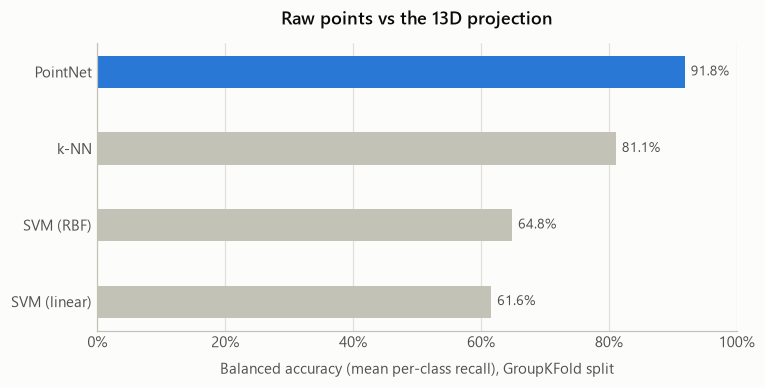

In [3]:
plot_df = (
    summary[summary["split"] == "groupkfold"]
    .assign(name=lambda d: d["model"].map(rio.pretty))
    .sort_values("balanced_accuracy")
)

fig, ax = plt.subplots(figsize=(7.5, 3.4))

# Emphasis: PointNet is the point of this notebook, the rest is context.
colors = [
    vs.BLUE if name == "PointNet" else vs.CONTEXT
    for name in plot_df["name"]
]

bars = ax.barh(plot_df["name"], plot_df["balanced_accuracy"] * 100,
               height=0.42, color=colors)
vs.label_bars(ax, bars, plot_df["balanced_accuracy"] * 100, fmt="{:.1f}%")

vs.percent_axis(ax, "x")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel("Balanced accuracy (mean per-class recall), GroupKFold split")
ax.set_title("Raw points vs the 13D projection")
plt.show()

92.8% against 64.8% for the best feature baseline. The geometry that separates
mug from box is *in the point cloud* - it is the projection to 13 numbers that
loses it, not the sensor.

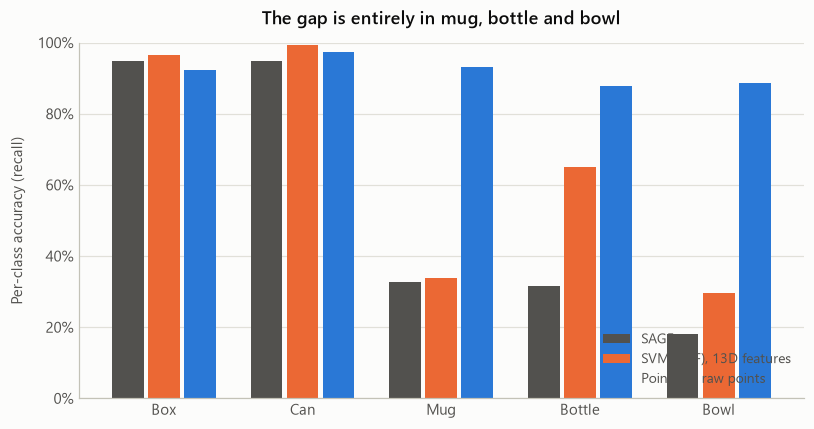

In [4]:
# Per-class, where the gap actually opens up.
sage = pd.Series(rio.SAGE)
pointnet = summary[summary["model"] == "pointnet_groupkfold"].iloc[0]
best_feature = summary[summary["model"] == "svm_rbf_groupkfold"].iloc[0]

series = {
    "SAGE": (sage, vs.SAGE_COLOR),
    "SVM (RBF), 13D features": (best_feature, vs.ORANGE),
    "PointNet, raw points": (pointnet, vs.BLUE),
}

fig, ax = plt.subplots(figsize=(8.5, 4.2))

vs.grouped_bars(
    ax,
    [c.capitalize() for c in rio.CLASSES],
    {
        name: ([row[f"{c}_accuracy"] * 100 for c in rio.CLASSES], color)
        for name, (row, color) in series.items()
    },
)

vs.percent_axis(ax, "y")
ax.set_ylabel("Per-class accuracy (recall)")
ax.set_title("The gap is entirely in mug, bottle and bowl")
ax.legend(loc="lower right")
plt.show()

Box and can are already solved by the 13D features - every method scores 93%+.
The entire difference is the three classes the feature set cannot express.

## Confusion matrix

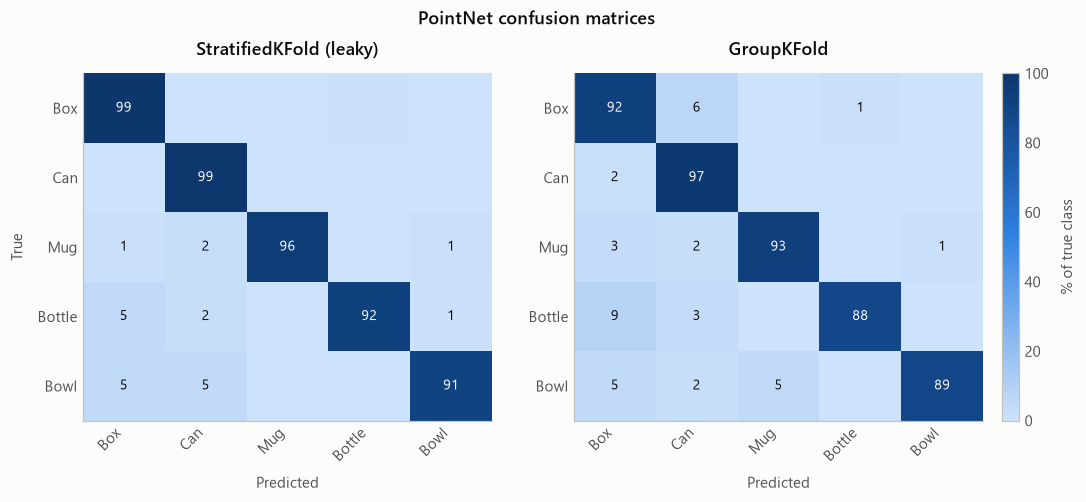

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

for ax, model in zip(axes, ["pointnet", "pointnet_groupkfold"]):
    matrix = rio.load_confusion(model, task="task2", normalize=True)
    image = ax.imshow(matrix.values, cmap=vs.SEQUENTIAL, vmin=0, vmax=100, aspect="auto")

    ax.set_xticks(range(len(rio.CLASSES)))
    ax.set_xticklabels([c.capitalize() for c in matrix.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(rio.CLASSES)))
    ax.set_yticklabels([c.capitalize() for c in matrix.index])

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.values[i, j]
            if value < 0.5:
                continue
            ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9,
                    color="white" if value > 55 else vs.INK)

    ax.set_title(rio.SPLIT_LABELS[rio.split_of(model)])
    ax.grid(False)
    ax.set_xlabel("Predicted")
    if ax is axes[0]:
        ax.set_ylabel("True")

fig.colorbar(image, ax=axes, label="% of true class", fraction=0.02, pad=0.02)
fig.suptitle("PointNet confusion matrices", y=1.02, fontsize=12, fontweight="semibold")
plt.show()

## Training behaviour

Worth a glance to confirm the folds converged rather than diverging or
memorising early.

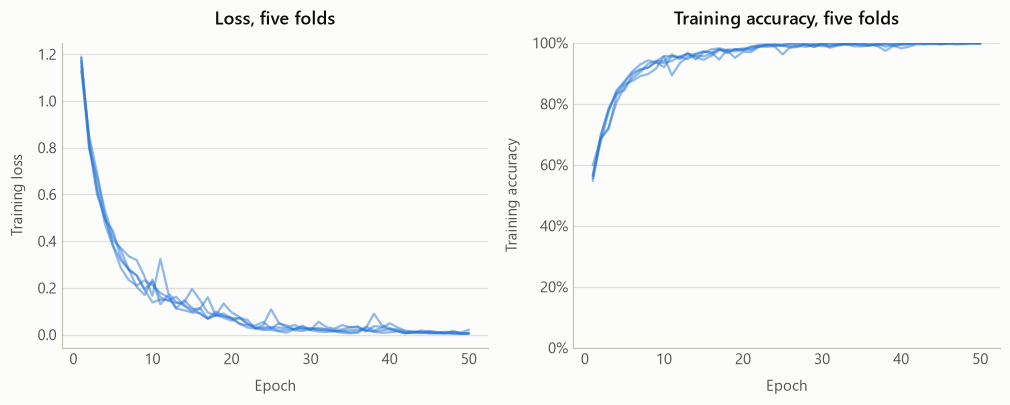

,fold,train_size,test_size,accuracy
0,1,895,214,95.33
1,2,821,288,89.93
2,3,928,181,96.69
3,4,879,230,94.35
4,5,913,196,91.33


In [6]:
history = pd.read_csv(rio.RESULTS_DIR / "task2" / "pointnet_groupkfold_training_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for fold, fold_df in history.groupby("fold"):
    axes[0].plot(fold_df["epoch"], fold_df["train_loss"],
                 color=vs.BLUE, alpha=0.5, linewidth=1.5)
    axes[1].plot(fold_df["epoch"], fold_df["train_accuracy"] * 100,
                 color=vs.BLUE, alpha=0.5, linewidth=1.5)

axes[0].set_ylabel("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_title("Loss, five folds")

axes[1].set_ylabel("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_title("Training accuracy, five folds")
vs.percent_axis(axes[1], "y")

fold_results = pd.read_csv(rio.RESULTS_DIR / "task2" / "pointnet_groupkfold_fold_results.csv")
plt.show()

fold_results.assign(accuracy=lambda d: (d["accuracy"] * 100).round(2))

Fold sizes are uneven here (`GroupKFold` balances size, not class mix), so
fold-to-fold accuracy varies more than it would under stratification. The
aggregate is an out-of-fold score over all 1109 instances, so it is not
resting on one lucky fold either way.

Training accuracy reaches ~100% while held-out accuracy sits well below it,
so the network does fit its training folds completely. That gap is expected
at this size and is *not* the leakage issue - these folds keep objects
whole, so the held-out objects were genuinely unseen.